<a href="https://colab.research.google.com/github/komronbekqayumov/firth-project/blob/main/Diabet_kasalligiga_tashxis_qo%CA%BByish_partfoliyo_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of data:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64

<ipython-input-1-7b61df152ece>:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)



Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.80      0.83      0.81        99
           1       0.67      0.62      0.64        55

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.73       154
weighted avg       0.75      0.75      0.75       154

Confusion Matrix:
 [[82 17]
 [21 34]]
Accuracy: 0.7532467532467533

Random Forest Results:
              precision    recall  f1-score   support

           0       0.80      0.79      0.79        99
           1       0.62      0.64      0.63        55

    accuracy                           0.73       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.73      0.73      0.73       154

Confusion Matrix:
 [[78 21]
 [20 35]]
Accuracy: 0.7337662337662337

Logistic Regression AUC: 0.82277318640955
Random Forest AUC: 0.8340679522497705


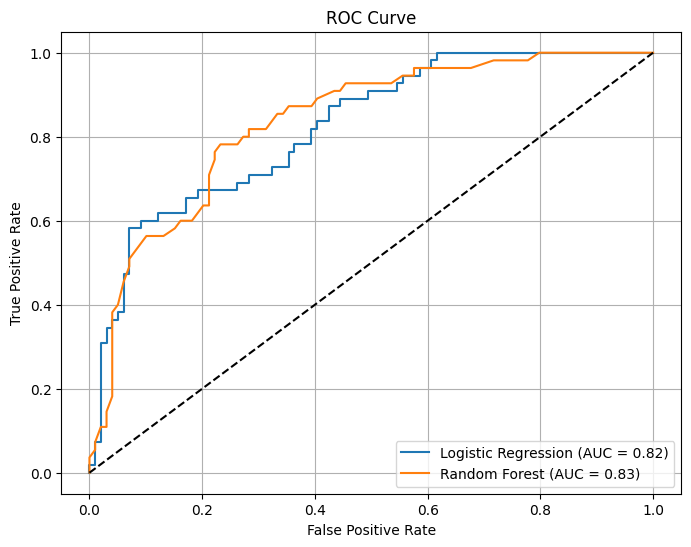

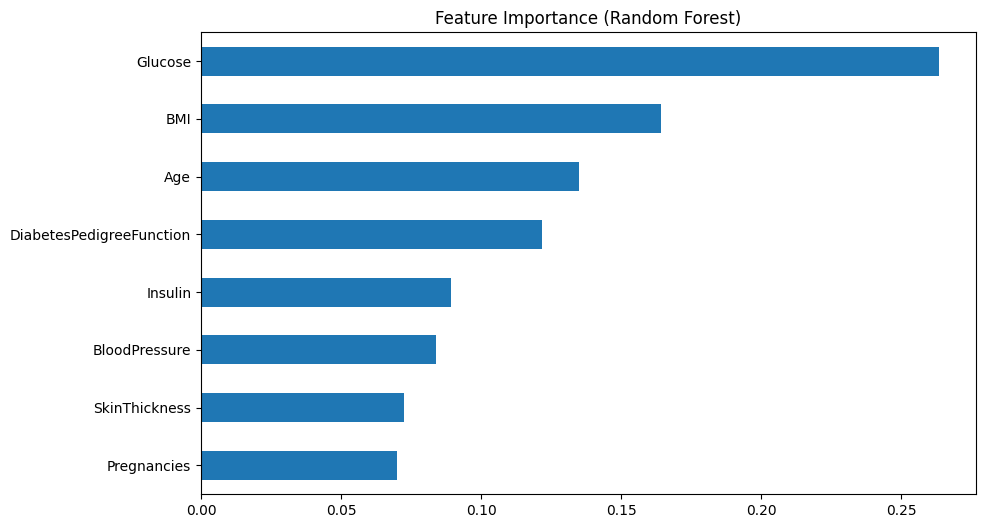

In [ ]:
# 1. Kutubxonalarni chaqirib olamiz
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# 2. Ma'lumotlarni yuklab olamiz
url = 'https://raw.githubusercontent.com/anvarnarz/praktikum_datasets/refs/heads/main/diabetes.csv'
df = pd.read_csv(url)

# 3. Ma'lumotlarni tekshirish
print("First 5 rows of data:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nMissing values check:")
print(df.isnull().sum())

# 4. Noto'g'ri qiymatlarni (0) aniqlaymiz
columns_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 0 qiymatlarni NaN qilib almashtiramiz
for col in columns_with_zero:
    df[col] = df[col].replace(0, np.nan)

# NaN qiymatlarni ustunning median qiymati bilan to'ldiramiz
for col in columns_with_zero:
    df[col].fillna(df[col].median(), inplace=True)

# 5. Cleaned datasetni ko‘rib chiqamiz
print("\nAfter cleaning missing values:")
print(df.isnull().sum())

# 6. Feature va Label’ni ajratamiz
X = df.drop('Outcome', axis=1)  # Features
y = df['Outcome']               # Label

# 7. Ma'lumotni train/test setlarga ajratamiz
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 8. Scaling - Normalizatsiya qilamiz
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 9. Model yaratamiz va train qilamiz (Logistic Regression va Random Forest)
log_model = LogisticRegression()
log_model.fit(X_train, y_train)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# 10. Modelni baholaymiz
# Logistic Regression baholash
y_pred_log = log_model.predict(X_test)
print("\nLogistic Regression Results:")
print(classification_report(y_test, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log))
print("Accuracy:", accuracy_score(y_test, y_pred_log))

# Random Forest baholash
y_pred_rf = rf_model.predict(X_test)
print("\nRandom Forest Results:")
print(classification_report(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

# 11. ROC Curve va AUC ko‘rsatkichlarini chizamiz
log_probs = log_model.predict_proba(X_test)[:, 1]
rf_probs = rf_model.predict_proba(X_test)[:, 1]

log_auc = roc_auc_score(y_test, log_probs)
rf_auc = roc_auc_score(y_test, rf_probs)

print("\nLogistic Regression AUC:", log_auc)
print("Random Forest AUC:", rf_auc)

# ROC curve chizish
fpr_log, tpr_log, _ = roc_curve(y_test, log_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {log_auc:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

# 12. Feature Importance (Random Forest uchun)
feature_importances = pd.Series(rf_model.feature_importances_, index=df.columns[:-1])
feature_importances.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title('Feature Importance (Random Forest)')
plt.show()


In [ ]:
# 13. Random Forest modelini GridSearchCV orqali tuning qilamiz
from sklearn.model_selection import GridSearchCV

# Parametrlar grid'ini belgilaymiz
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
}

# GridSearchCV object yaratamiz
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=1
)

# Train qilamiz
grid_search.fit(X_train, y_train)

# Eng yaxshi parametrlar
print("\nBest parameters found by GridSearchCV:")
print(grid_search.best_params_)

# Eng yaxshi model bilan predict qilamiz
best_rf_model = grid_search.best_estimator_
y_pred_best_rf = best_rf_model.predict(X_test)

# Baholaymiz
print("\nBest Random Forest Results (after tuning):")
print(classification_report(y_test, y_pred_best_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_best_rf))


Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters found by GridSearchCV:
{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}

Best Random Forest Results (after tuning):
              precision    recall  f1-score   support

           0       0.83      0.79      0.81        99
           1       0.65      0.71      0.68        55

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154

Confusion Matrix:
 [[78 21]
 [16 39]]
Accuracy: 0.7597402597402597


In [ ]:
# 14. Eng yaxshi modelni saqlaymiz (.pkl faylga)
import pickle

# Modelni saqlash
filename = 'best_diabetes_model.pkl'
with open(filename, 'wb') as file:
    pickle.dump(best_rf_model, file)

print(f"\nModel '{filename}' nomli faylga saqlandi.")



Model 'best_diabetes_model.pkl' nomli faylga saqlandi.


In [ ]:
# 15. Saqlangan modelni yuklaymiz va yangi predict qilamiz

# Modelni yuklab olamiz
with open(filename, 'rb') as file:
    loaded_model = pickle.load(file)

# Misol uchun yangi bir bemorning ma'lumotlari
new_data = np.array([[2, 120, 70, 25, 80, 30.5, 0.5, 32]])  # random sample

# Scaling qilish (chunki trainingda scaling qilingan)
new_data_scaled = scaler.transform(new_data)

# Predict qilish
prediction = loaded_model.predict(new_data_scaled)

if prediction[0] == 1:
    print("\nNew patient prediction: Diabet bor.")
else:
    print("\nNew patient prediction: Diabet yo'q.")



New patient prediction: Diabet yo'q.


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
